# Fraud Detection – Threshold Tuning

Objective:
- Analyze probability outputs of XGBoost
- Test multiple decision thresholds
- Balance recall and precision
- Select optimal threshold for deployment

In [15]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score
from xgboost import XGBClassifier

In [16]:
X_train = joblib.load("../data/X_train_processed.pkl")
X_test = joblib.load("../data/X_test_processed.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

In [17]:
fraud = np.sum(y_train == 1)
non_fraud = np.sum(y_train == 0)

scale_pos_weight = non_fraud / fraud

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [18]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [19]:
thresholds = [0.5, 0.8, 0.9, 0.95]

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    results.append([t, precision, recall])

results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall"])
results_df

,Threshold,Precision,Recall
0,0.50,0.309079,0.976389
1,0.80,0.530469,0.943056
2,0.90,0.636852,0.904861
3,0.95,0.741071,0.864583


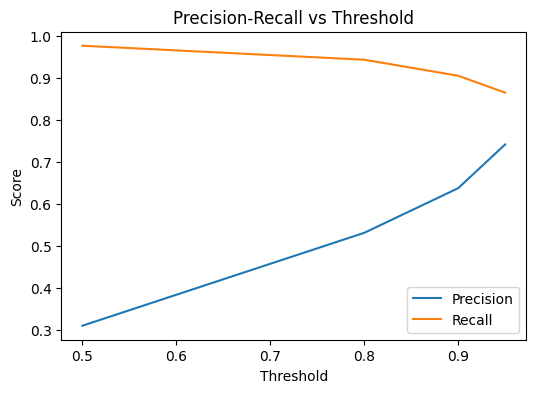

In [20]:
plt.figure(figsize=(6,4))
plt.plot(results_df["Threshold"], results_df["Precision"], label="Precision")
plt.plot(results_df["Threshold"], results_df["Recall"], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision-Recall vs Threshold")
plt.show()

In [21]:
final_threshold = 0.95

joblib.dump(final_threshold, "../models/threshold.pkl")

['../models/threshold.pkl']

# Threshold Tuning Summary

1. Default threshold (0.5) gives high recall but low precision.
2. Increasing threshold improves precision.
3. Threshold 0.95 provides balanced fraud detection.
4. Selected threshold = 0.95 for deployment.